In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier)

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

df = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
# Data cleaning & initial inspection
df = df.drop(columns=["id"])

# The dataset contains a single "Other" gender record.
# Keep the modeling scope consistent with the original notebook by excluding this one rare category.
df = df[df["gender"] != "Other"].reset_index(drop=True)

print("Shape after initial cleaning:", df.shape)
display(df.isna().sum())


Shape after initial cleaning: (5109, 11)


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


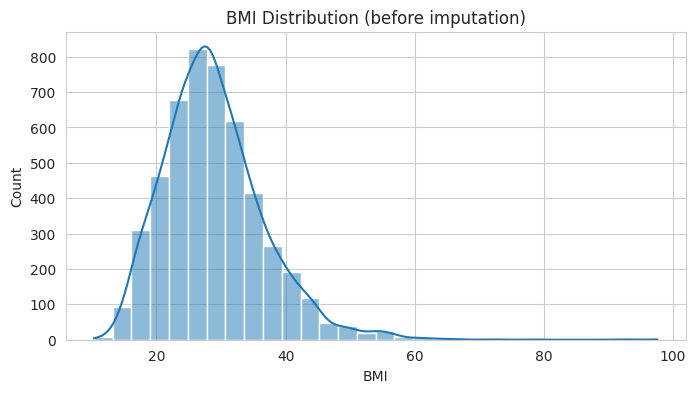

Missing BMI values: 201


In [3]:
# Inspect BMI before imputation
plt.figure(figsize=(8, 4))
sns.histplot(df["bmi"].dropna(), kde=True, bins=30)
plt.title("BMI Distribution (before imputation)")
plt.xlabel("BMI")
plt.show()

print("Missing BMI values:", df["bmi"].isna().sum())


In [4]:
df.shape

(5109, 11)

In [5]:
# Encode categorical columns
binary_maps = {
    "gender": {"Male": 1, "Female": 0},
    "ever_married": {"Yes": 1, "No": 0},
    "Residence_type": {"Urban": 1, "Rural": 0},
}

for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)

# Multi-category columns -> one-hot encode
df = pd.get_dummies(
    df,
    columns=["work_type", "smoking_status"],
    drop_first=True,
    dtype=int
)

# Confirm that all features except BMI are complete.
print("Missing values after encoding:")
display(df.isna().sum())

print("\nData types:")
display(df.dtypes)

Missing values after encoding:


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
Residence_type,0
avg_glucose_level,0
bmi,201
stroke,0
work_type_Never_worked,0



Data types:


,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
ever_married,int64
Residence_type,int64
avg_glucose_level,float64
bmi,float64
stroke,int64
work_type_Never_worked,int64


In [6]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0,1,0,0,1,0,0
1,0,61.0,0,0,1,0,202.21,NaN,1,0,0,1,0,0,1,0
2,1,80.0,0,1,1,0,105.92,32.5,1,0,1,0,0,0,1,0
3,0,49.0,0,0,1,1,171.23,34.4,1,0,1,0,0,0,0,1
4,0,79.0,1,0,1,0,174.12,24.0,1,0,0,1,0,0,1,0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,5109.0,0.413975,0.492592,0.00,0.00,0.00,1.00,1.00
age,5109.0,43.229986,22.613575,0.08,25.00,45.00,61.00,82.00
hypertension,5109.0,0.097475,0.296633,0.00,0.00,0.00,0.00,1.00
heart_disease,5109.0,0.054022,0.226084,0.00,0.00,0.00,0.00,1.00
ever_married,5109.0,0.656293,0.474991,0.00,0.00,1.00,1.00,1.00
Residence_type,5109.0,0.508123,0.499983,0.00,0.00,1.00,1.00,1.00
avg_glucose_level,5109.0,106.140399,45.285004,55.12,77.24,91.88,114.09,271.74
bmi,4908.0,28.894560,7.854320,10.30,23.50,28.10,33.10,97.60
stroke,5109.0,0.048738,0.215340,0.00,0.00,0.00,0.00,1.00
work_type_Never_worked,5109.0,0.004306,0.065486,0.00,0.00,0.00,0.00,1.00


In [8]:
target_counts = df["stroke"].value_counts()
print(target_counts)
print("\nClass balance (%):")
print((target_counts / len(df) * 100).round(2))


stroke
0    4860
1     249
Name: count, dtype: int64

Class balance (%):
stroke
0    95.13
1     4.87
Name: count, dtype: float64


In [9]:
corr = df.corr(numeric_only=True)
corr["stroke"].sort_values(ascending=False)


,stroke
stroke,1.000000
age,0.245239
heart_disease,0.134905
avg_glucose_level,0.131991
hypertension,0.127891
ever_married,0.108299
smoking_status_formerly smoked,0.064683
work_type_Self-employed,0.062150
bmi,0.042341
Residence_type,0.015415


/tmp/ipykernel_45538/1330043757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="stroke", palette="Set2")


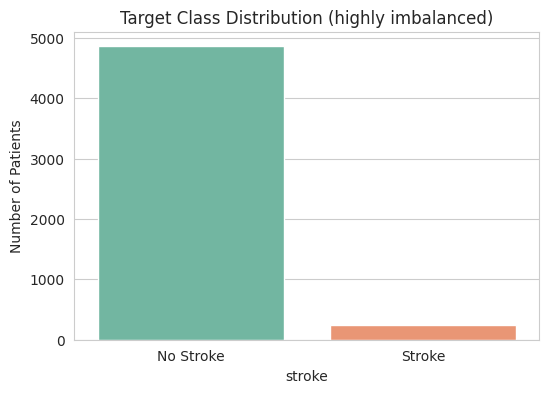

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke", palette="Set2")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.title("Target Class Distribution (highly imbalanced)")
plt.ylabel("Number of Patients")
plt.show()

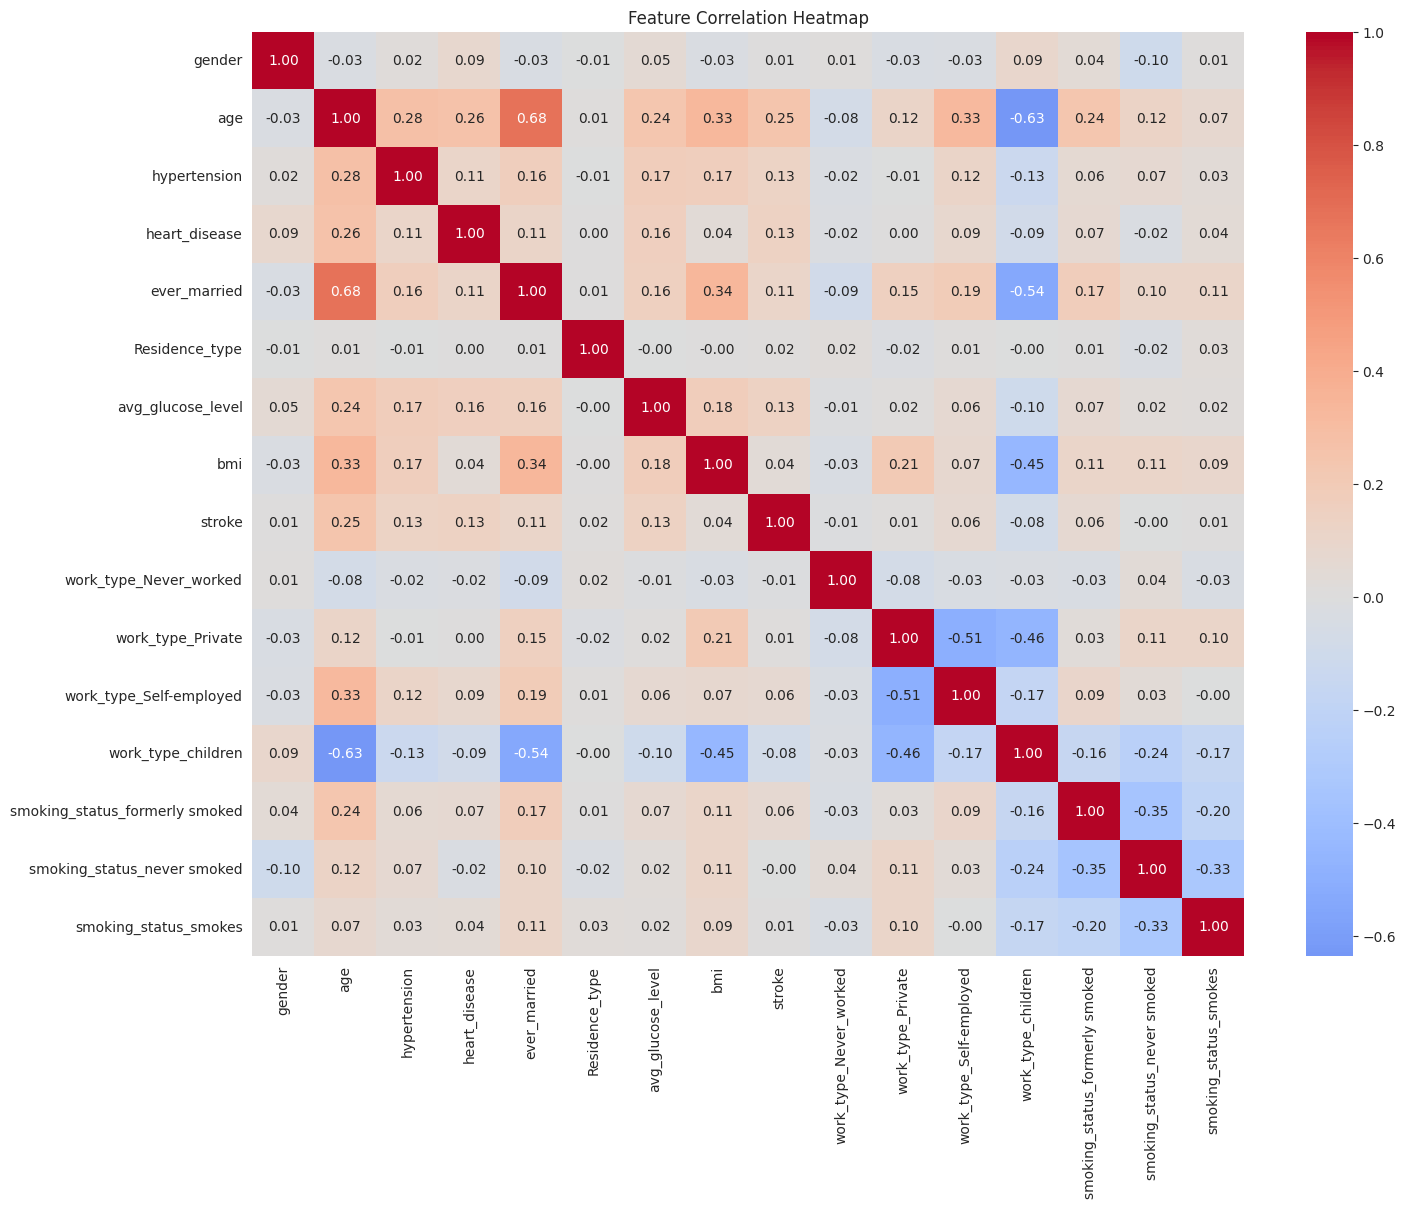

In [11]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


/tmp/ipykernel_45538/3011789935.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Stroke", "Stroke"])
/tmp/ipykernel_45538/3011789935.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Stroke", "Stroke"])
/tmp/ipykernel_45538/3011789935.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Stroke", "Stroke"])


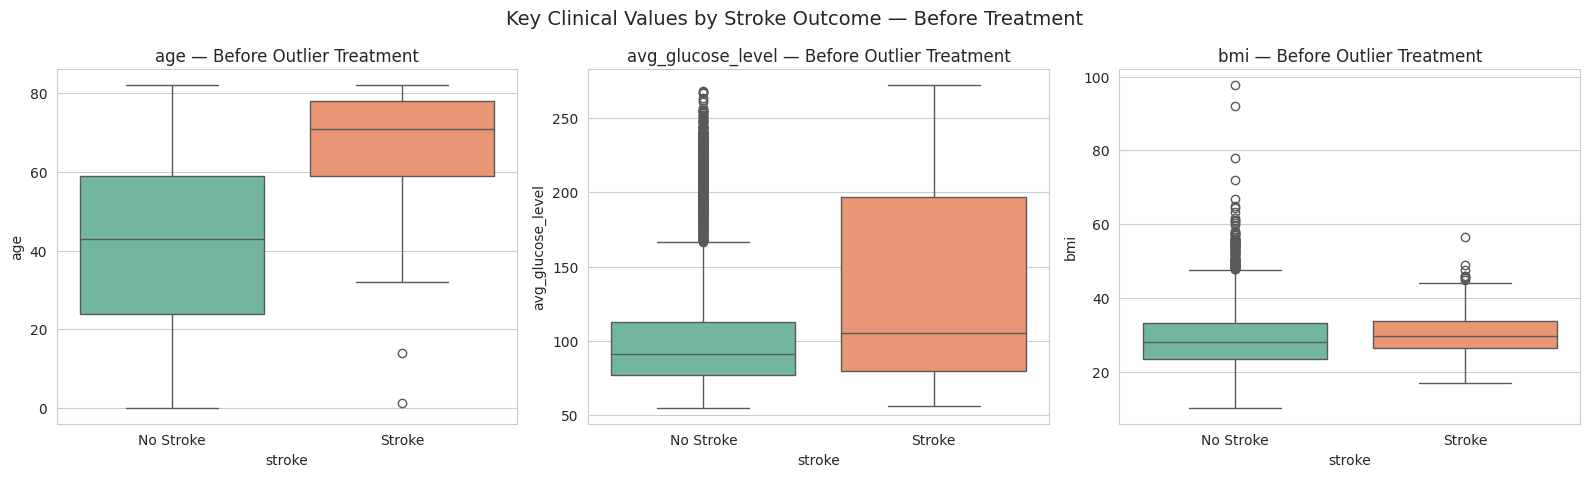

In [12]:
# Box plots BEFORE outlier treatment
# Important: points beyond the whiskers are statistical outliers, not automatically invalid patients.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, feat in zip(axes, ["age", "avg_glucose_level", "bmi"]):
    sns.boxplot(
        data=df,
        x="stroke",
        y=feat,
        hue="stroke",
        ax=ax,
        palette="Set2",
        legend=False
    )
    ax.set_xticklabels(["No Stroke", "Stroke"])
    ax.set_title(f"{feat} — Before Outlier Treatment")

plt.tight_layout()
plt.suptitle("Key Clinical Values by Stroke Outcome — Before Treatment", y=1.05, fontsize=14)
plt.show()


/tmp/ipykernel_45538/3068546187.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Hypertension", "Hypertension"])
/tmp/ipykernel_45538/3068546187.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Heart Disease", "Heart Disease"])


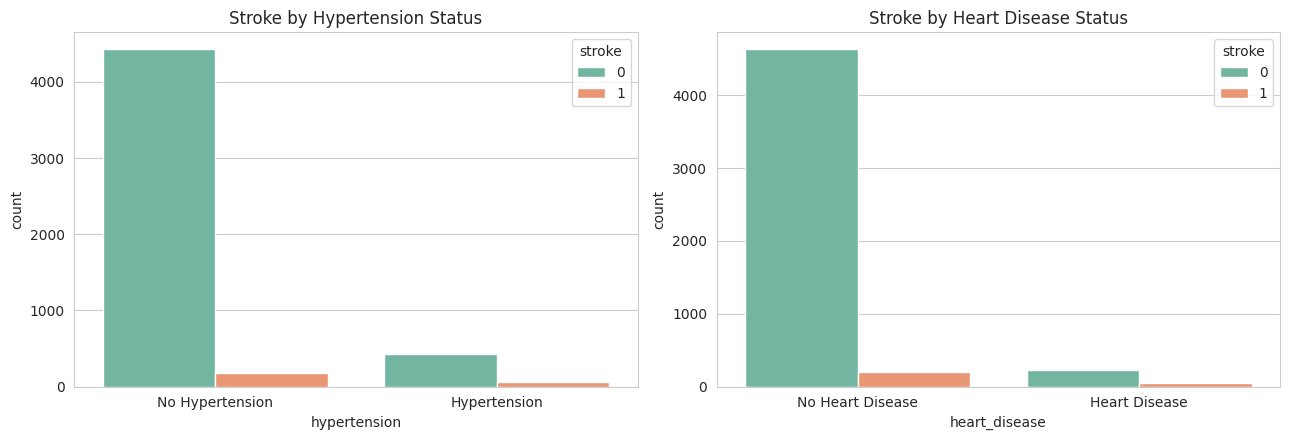

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df, x="hypertension", hue="stroke", ax=axes[0], palette="Set2")
axes[0].set_title("Stroke by Hypertension Status")
axes[0].set_xticklabels(["No Hypertension", "Hypertension"])

sns.countplot(data=df, x="heart_disease", hue="stroke", ax=axes[1], palette="Set2")
axes[1].set_title("Stroke by Heart Disease Status")
axes[1].set_xticklabels(["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.show()


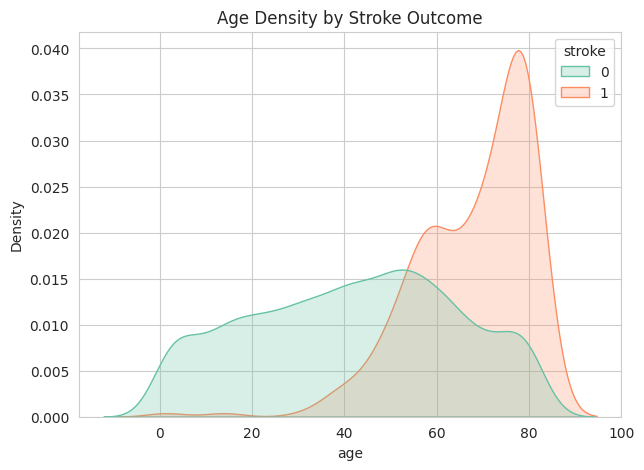

In [14]:
plt.figure(figsize=(7, 5))
sns.kdeplot(data=df, x="age", hue="stroke", fill=True, common_norm=False, palette="Set2")
plt.title("Age Density by Stroke Outcome")
plt.show()


In [15]:
# Train/Test split BEFORE fitting preprocessing steps
# This prevents information from the test set from influencing imputation or outlier limits.

X = df.drop(columns=["stroke"]).copy()
y = df["stroke"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)


# 1) Missing-value imputation
# Fit the median ONLY on the training set, then apply it to both sets.
imputer = SimpleImputer(strategy="median")

X_train["bmi"] = imputer.fit_transform(X_train[["bmi"]]).ravel()
X_test["bmi"] = imputer.transform(X_test[["bmi"]]).ravel()

# 2) IQR outlier treatment
# The IQR limits are learned ONLY from X_train.
# This preserves observations while reducing the influence of extreme values.

outlier_features = ["age", "avg_glucose_level", "bmi"]

def fit_iqr_caps(data, columns, multiplier=1.5):
    caps = {}
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        caps[col] = {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower": q1 - multiplier * iqr,
            "Upper": q3 + multiplier * iqr,
        }
    return pd.DataFrame(caps).T

def apply_iqr_caps(data, caps):
    data = data.copy()
    for col in caps.index:
        data[col] = data[col].clip(
            lower=caps.loc[col, "Lower"],
            upper=caps.loc[col, "Upper"]
        )
    return data

iqr_caps = fit_iqr_caps(X_train, outlier_features)

# Show the limits learned from TRAIN only.
print("IQR limits learned from the training set:")
display(iqr_caps.round(3))

def count_iqr_outliers(data, caps):
    rows = []
    for col in caps.index:
        lower = caps.loc[col, "Lower"]
        upper = caps.loc[col, "Upper"]
        mask = (data[col] < lower) | (data[col] > upper)
        rows.append({
            "Feature": col,
            "Outliers": int(mask.sum()),
            "Percentage": float(mask.mean() * 100)
        })
    return pd.DataFrame(rows).set_index("Feature")

print("Training-set outliers BEFORE capping:")
display(count_iqr_outliers(X_train, iqr_caps).round(2))

X_train = apply_iqr_caps(X_train, iqr_caps)
X_test = apply_iqr_caps(X_test, iqr_caps)

print("Training-set outliers AFTER capping:")
display(count_iqr_outliers(X_train, iqr_caps).round(2))

print("Missing values after preprocessing:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

print(
    "\nTrain shape:", X_train.shape,
    "| Test shape:", X_test.shape
)
print(
    "Train stroke rate: {:.2%} | Test stroke rate: {:.2%}".format(
        y_train.mean(), y_test.mean()
    )
)


IQR limits learned from the training set:


,Q1,Q3,IQR,Lower,Upper
age,25.000,61.00,36.000,-29.000,115.000
avg_glucose_level,77.515,113.63,36.115,23.343,167.802
bmi,23.700,32.70,9.000,10.200,46.200


Training-set outliers BEFORE capping:


,Outliers,Percentage
Feature,,
age,0,0.00
avg_glucose_level,455,11.88
bmi,95,2.48


Training-set outliers AFTER capping:


,Outliers,Percentage
Feature,,
age,0,0.0
avg_glucose_level,0,0.0
bmi,0,0.0


Missing values after preprocessing:
X_train: 0
X_test : 0

Train shape: (3831, 15) | Test shape: (1278, 15)
Train stroke rate: 4.88% | Test stroke rate: 4.85%


/tmp/ipykernel_45538/3064786078.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Stroke", "Stroke"])
/tmp/ipykernel_45538/3064786078.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Stroke", "Stroke"])
/tmp/ipykernel_45538/3064786078.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Stroke", "Stroke"])


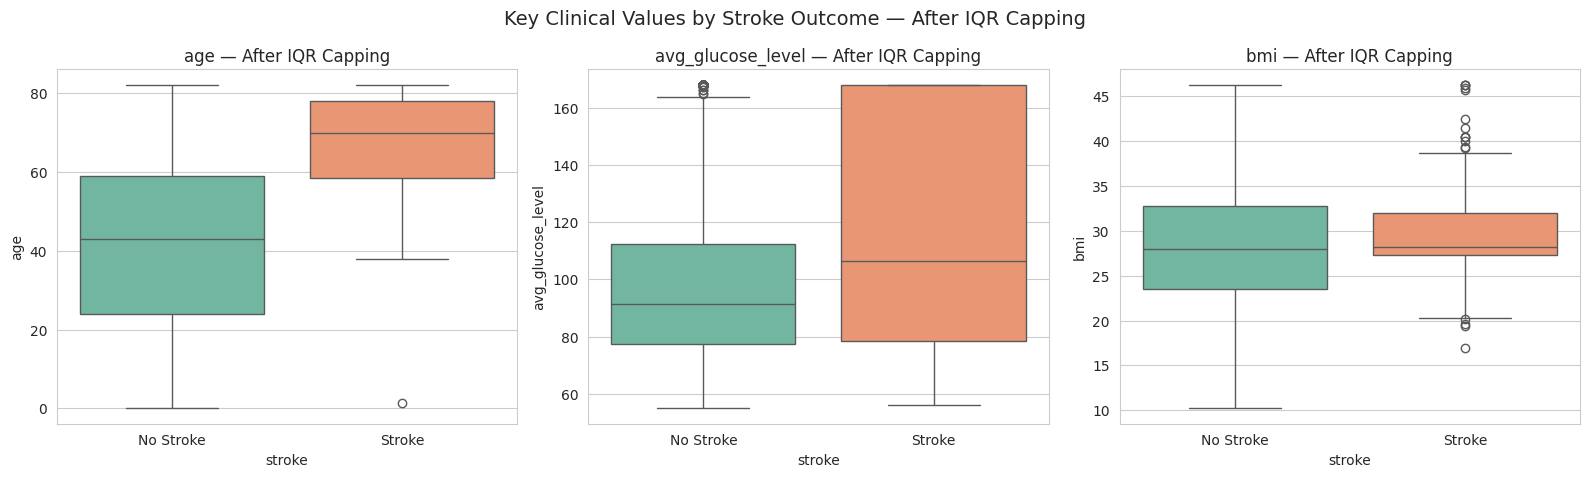

In [16]:
# Box plots AFTER outlier treatment
# X_train has already been imputed and capped in the preprocessing cell above.
plot_train = X_train.copy()
plot_train["stroke"] = y_train.to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, feat in zip(axes, outlier_features):
    sns.boxplot(
        data=plot_train,
        x="stroke",
        y=feat,
        hue="stroke",
        ax=ax,
        palette="Set2",
        legend=False
    )
    ax.set_xticklabels(["No Stroke", "Stroke"])
    ax.set_title(f"{feat} — After IQR Capping")

plt.tight_layout()
plt.suptitle("Key Clinical Values by Stroke Outcome — After IQR Capping", y=1.05, fontsize=14)
plt.show()


In [17]:
results = {}
fitted_models = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, sample_weight=None):
    if sample_weight is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)
    fitted_models[name] = model
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else preds

    metrics = {
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds, zero_division=0),
        "Recall": recall_score(y_te, preds, zero_division=0),
        "F1": f1_score(y_te, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, probs),
    }
    results[name] = metrics

    print(f"\n=== {name} ===")
    print(classification_report(y_te, preds, target_names=["No Stroke", "Stroke"], zero_division=0))

    cm = confusion_matrix(y_te, preds)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return model



=== Decision Tree ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.66      0.79      1216
      Stroke       0.10      0.74      0.18        62

    accuracy                           0.66      1278
   macro avg       0.54      0.70      0.48      1278
weighted avg       0.94      0.66      0.76      1278



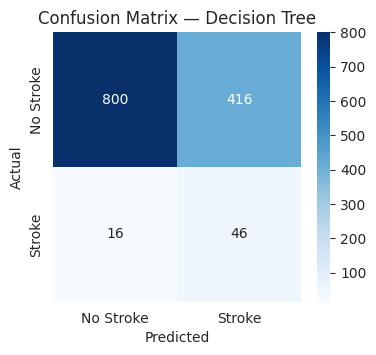

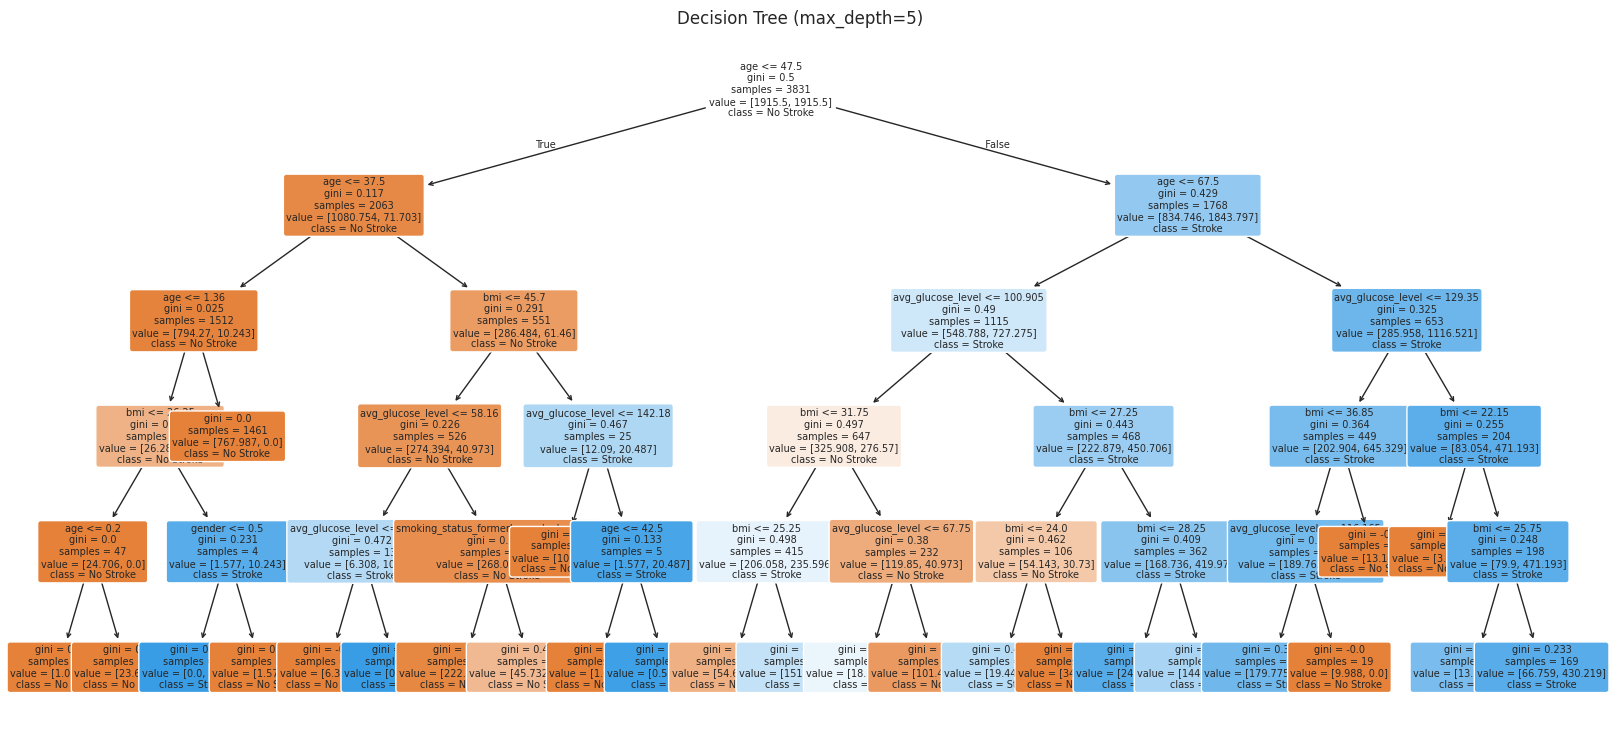

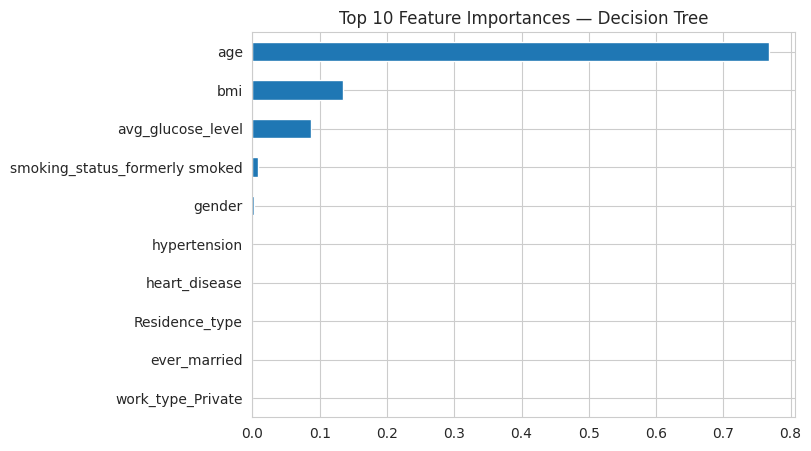

In [18]:
#Decision Tree
dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)
dt = evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test)

plt.figure(figsize=(20, 9))
plot_tree(dt, feature_names=X.columns, class_names=["No Stroke", "Stroke"],
          filled=True, rounded=True, fontsize=7)
plt.title("Decision Tree (max_depth=5)")
plt.show()

importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind="barh", figsize=(7, 5), title="Top 10 Feature Importances — Decision Tree")
plt.gca().invert_yaxis()
plt.show()



=== SVM (RBF kernel) ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.77      0.86      1216
      Stroke       0.13      0.65      0.21        62

    accuracy                           0.77      1278
   macro avg       0.55      0.71      0.54      1278
weighted avg       0.94      0.77      0.83      1278



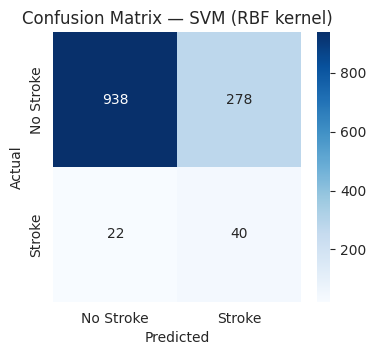

In [19]:
#Support Vector Machine (SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm = evaluate_model("SVM (RBF kernel)", svm, X_train_scaled, y_train, X_test_scaled, y_test)



=== Random Forest ===
              precision    recall  f1-score   support

   No Stroke       0.97      0.87      0.92      1216
      Stroke       0.15      0.45      0.22        62

    accuracy                           0.85      1278
   macro avg       0.56      0.66      0.57      1278
weighted avg       0.93      0.85      0.88      1278



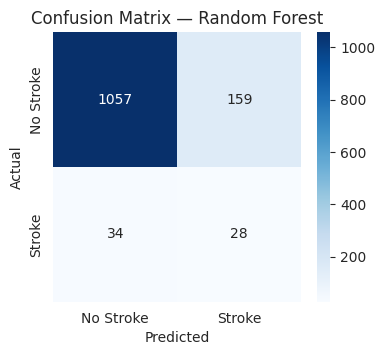

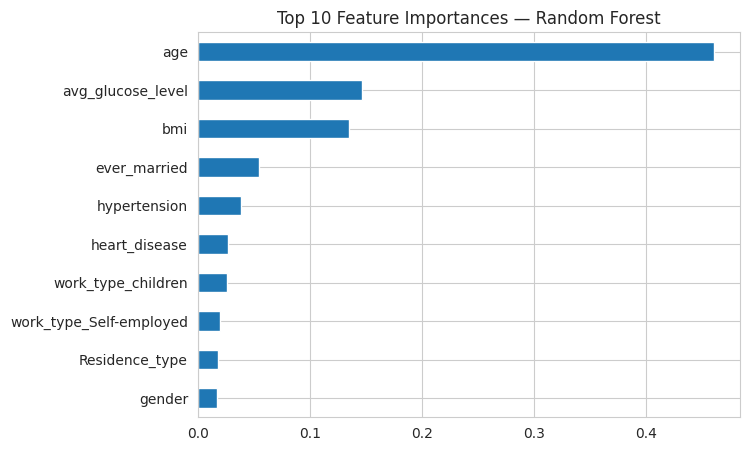

In [20]:
# Ensemble Learning(Random Forest)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                            random_state=RANDOM_STATE)
rf = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances_rf.head(10).plot(kind="barh", figsize=(7, 5), title="Top 10 Feature Importances — Random Forest")
plt.gca().invert_yaxis()
plt.show()



=== Bagging (Decision Tree base) ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.77      0.87      1216
      Stroke       0.14      0.73      0.24        62

    accuracy                           0.77      1278
   macro avg       0.56      0.75      0.55      1278
weighted avg       0.94      0.77      0.84      1278



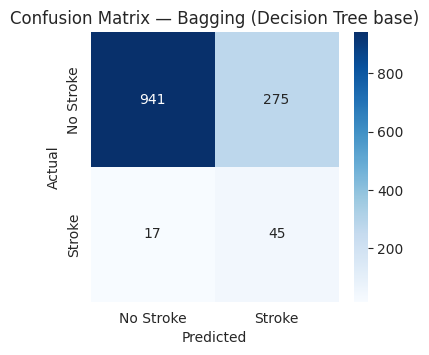

In [21]:
# Ensemble Learning (Bagging)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE),
    n_estimators=150, random_state=RANDOM_STATE
)
bagging = evaluate_model("Bagging (Decision Tree base)", bagging, X_train, y_train, X_test, y_test)



=== AdaBoost ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.71      0.82      1216
      Stroke       0.12      0.77      0.21        62

    accuracy                           0.71      1278
   macro avg       0.55      0.74      0.51      1278
weighted avg       0.94      0.71      0.79      1278



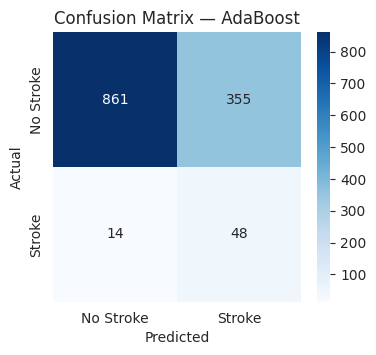


=== Gradient Boosting ===
              precision    recall  f1-score   support

   No Stroke       0.97      0.85      0.91      1216
      Stroke       0.15      0.52      0.23        62

    accuracy                           0.84      1278
   macro avg       0.56      0.68      0.57      1278
weighted avg       0.93      0.84      0.88      1278



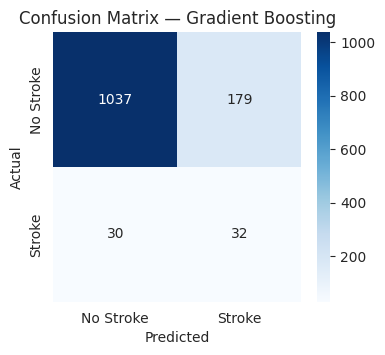

In [22]:
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

adaboost = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
adaboost = evaluate_model("AdaBoost", adaboost, X_train, y_train, X_test, y_test,
                           sample_weight=sample_weight)

gboost = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE)
gboost = evaluate_model("Gradient Boosting", gboost, X_train, y_train, X_test, y_test,
                         sample_weight=sample_weight)


,Accuracy,Precision,Recall,F1,ROC-AUC
AdaBoost,0.711,0.119,0.774,0.206,0.826
Decision Tree,0.662,0.100,0.742,0.176,0.788
Bagging (Decision Tree base),0.772,0.141,0.726,0.236,0.822
SVM (RBF kernel),0.765,0.126,0.645,0.211,0.777
Gradient Boosting,0.836,0.152,0.516,0.234,0.792
Random Forest,0.849,0.150,0.452,0.225,0.797


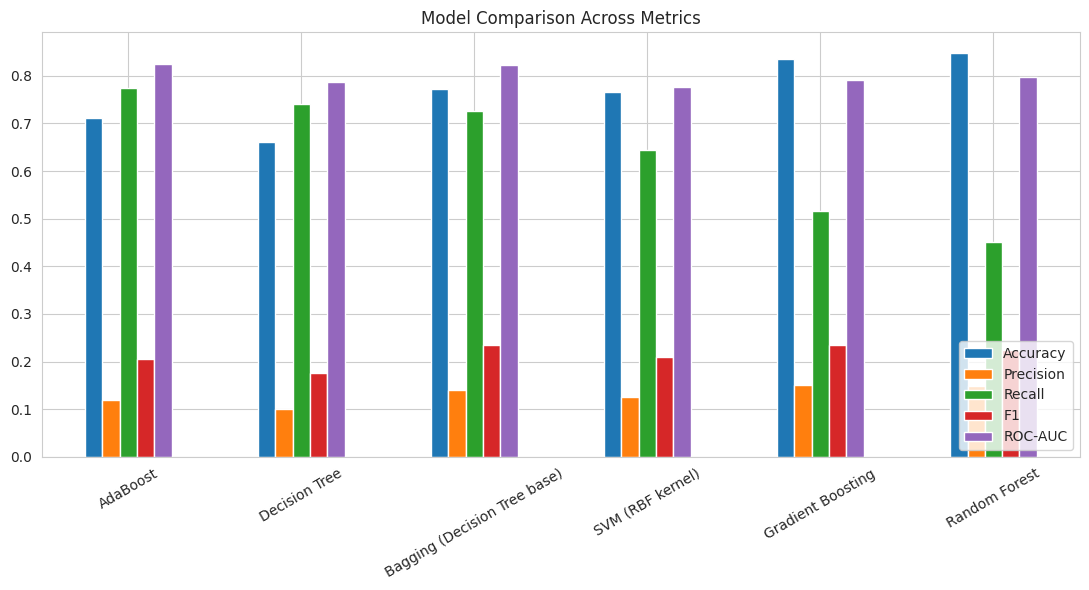

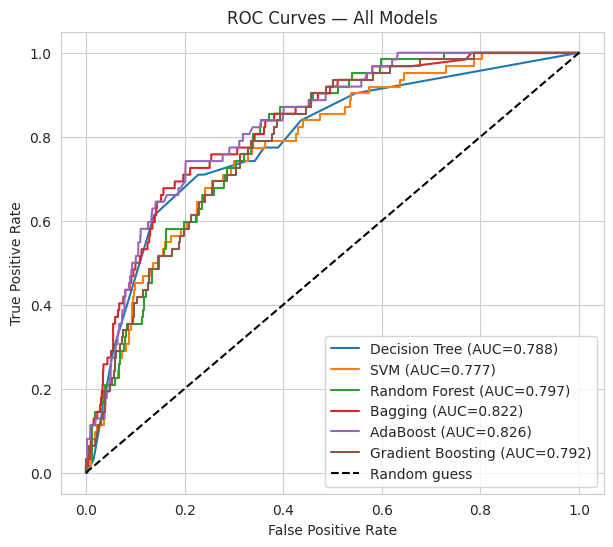

In [23]:
# Model evaluation & Comparison
results_df = pd.DataFrame(results).T.sort_values("Recall", ascending=False)
display(results_df.style.background_gradient(cmap="Greens").format("{:.3f}"))

results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(11, 6), rot=30
)
plt.title("Model Comparison Across Metrics")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
models_for_roc = {"Decision Tree": dt, "SVM": svm, "Random Forest": rf,
                   "Bagging": bagging, "AdaBoost": adaboost, "Gradient Boosting": gboost}

for name, model in models_for_roc.items():
    X_te = X_test_scaled if name == "SVM" else X_test
    probs = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

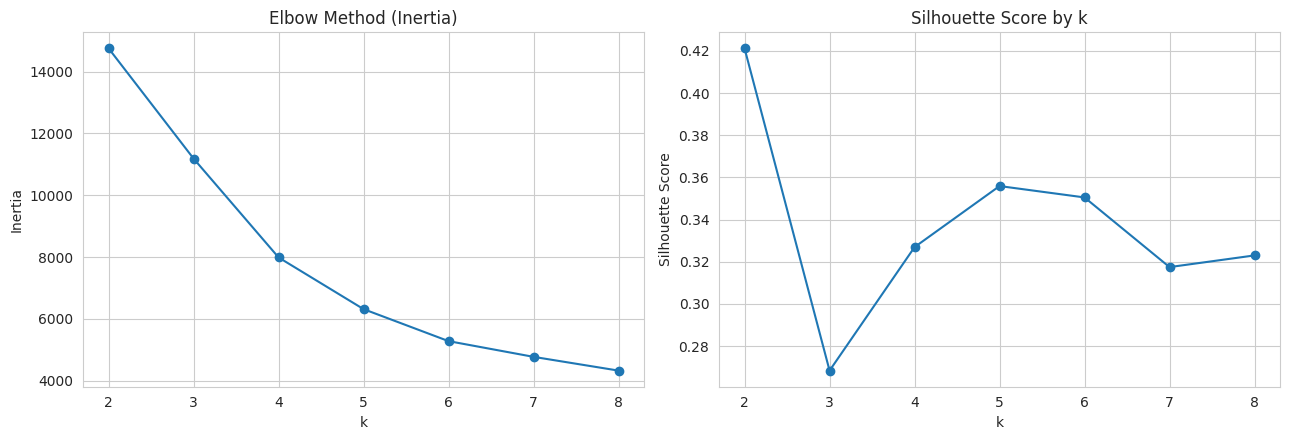

Use the elbow and silhouette plots above to justify K_CHOSEN.


In [24]:
# Unsupervised Learning
# Use a manageable, information-rich subset of features for clustering.
# Clustering is performed on the TRAINING data only to avoid test-set leakage.

cluster_features = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]

cluster_scaler = StandardScaler()
X_unsup = cluster_scaler.fit_transform(X_train[cluster_features])

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_unsup)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_unsup, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print("Use the elbow and silhouette plots above to justify K_CHOSEN.")


In [25]:
K_CHOSEN = 2  # pick based on the elbow/silhouette plot above
kmeans = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X_unsup)

# Profile each cluster by its average feature values + stroke rate
profile = X_train[cluster_features].copy()
profile["cluster"] = km_labels
profile["stroke"] = y_train.values
profile.groupby("cluster").agg(["mean", "count"]).round(2)


age       avg_glucose_level          bmi       hypertension        \
          mean count              mean count   mean count         mean count   
cluster                                                                        
0        38.12  3047             92.39  3047  27.68  3047         0.00  3047   
1        63.36   784            132.41   784  32.35   784         0.45   784   

        heart_disease       stroke        
                 mean count   mean count  
cluster                                   
0                0.00  3047   0.03  3047  
1                0.28   784   0.13   784

In [26]:
stroke_rate_by_cluster = profile.groupby("cluster")["stroke"].mean().sort_values(ascending=False)
print("Stroke rate by K-Means cluster:")
print((stroke_rate_by_cluster * 100).round(2).astype(str) + "%")


Stroke rate by K-Means cluster:
cluster
1    13.39%
0     2.69%
Name: stroke, dtype: object


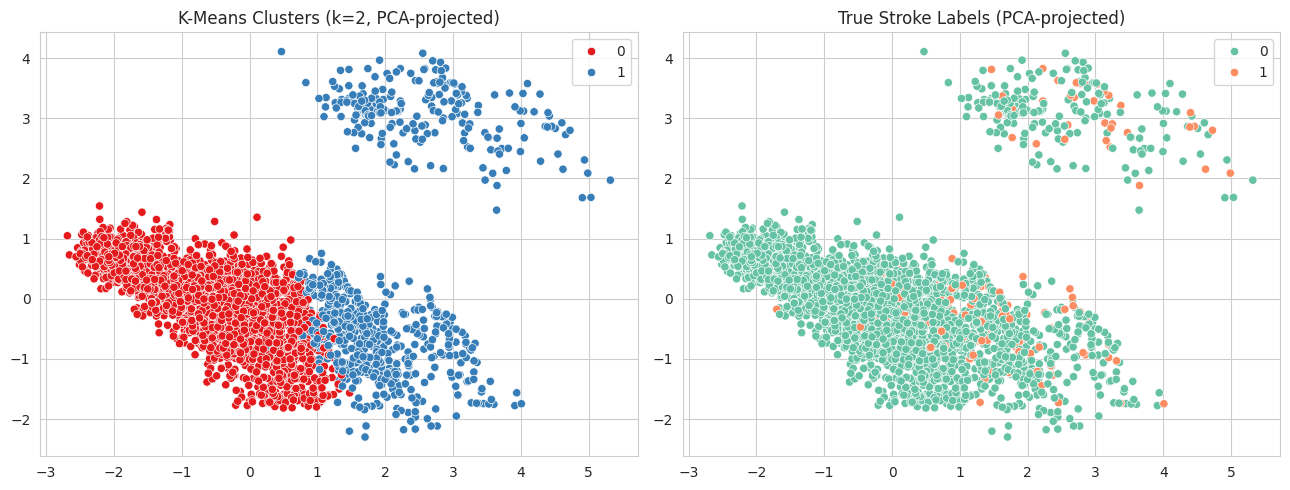

Explained variance by 2 PCA components: 54.5%


In [27]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_unsup)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=km_labels, palette="Set1", ax=axes[0])
axes[0].set_title(f"K-Means Clusters (k={K_CHOSEN}, PCA-projected)")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train.values, palette="Set2", ax=axes[1])
axes[1].set_title("True Stroke Labels (PCA-projected)")
plt.tight_layout()
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.1%}")



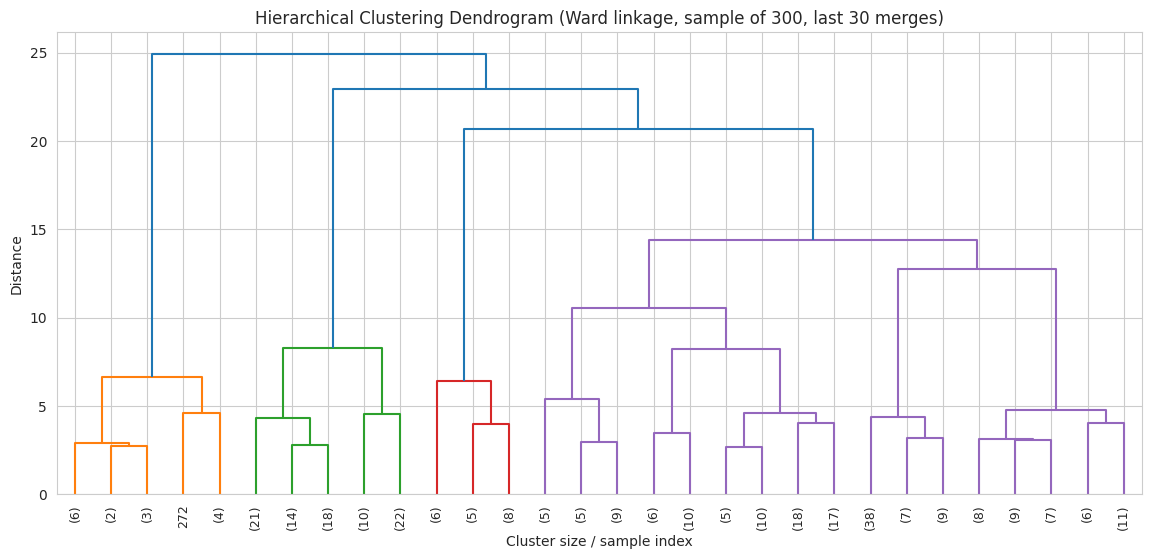

In [28]:
# Hierarchical Clustering
# Dendrogram on a random sample of 300 patients for readability
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_unsup), size=300, replace=False)
linked = linkage(X_unsup[sample_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, sample of 300, last 30 merges)")
plt.xlabel("Cluster size / sample index")
plt.ylabel("Distance")
plt.show()

In [29]:
agg = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage="ward")
agg_labels = agg.fit_predict(X_unsup)

print("Silhouette score (Agglomerative, k={}):".format(K_CHOSEN), silhouette_score(X_unsup, agg_labels))

ari_kmeans = adjusted_rand_score(y_train, km_labels)
ari_agg = adjusted_rand_score(y_train, agg_labels)
print(f"\nAdjusted Rand Index — K-Means vs true stroke labels: {ari_kmeans:.3f}")
print(f"Adjusted Rand Index — Agglomerative vs true stroke labels: {ari_agg:.3f}")


Silhouette score (Agglomerative, k=2): 0.48735290914656665

Adjusted Rand Index — K-Means vs true stroke labels: 0.111
Adjusted Rand Index — Agglomerative vs true stroke labels: 0.115
